**NB08** This notebook is targeted towards finding patterns and signals for News API coverage on the 96-Company Stress-Test sample that viktori generated 

Testing news coverage on te balanced 96-company grid (NB04), that now includes **Large** companies

My main aim for this task is :
1. Test The Guardian API + Newscatcher API with Viktor's query templates
2. Run a sentiment analysis on any of articles found
3. compare coverage rates across tiers (i.e does large tier change the scenario)
4. Output should be a structured signals table that can feed into the spine frame work samuele has created.

In [1]:
#Import block
import pandas as pd
import requests
import time
import json
import re
from datetime import datetime, timedelta
from collections import defaultdict
from pathlib import Path

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Resolve paths relative to this notebook's location (automates so no need to put path manually)
NOTEBOOK_DIR = Path.cwd()  # This works in Jupyter
PROJECT_ROOT = NOTEBOOK_DIR.parent  # assumes notebook is in /notebooks

# Look for the sample in order of likelihood
_candidates = [
    PROJECT_ROOT / "data" / "processed" / "nb04_stress_test_sample.csv",
    PROJECT_ROOT.parent / "data" / "processed" / "nb04_stress_test_sample.csv",  
]

SAMPLE_PATH = None
for p in _candidates:
    if p.exists():
        SAMPLE_PATH = p
        break

if SAMPLE_PATH is None:
    raise FileNotFoundError(
        f"nb04_stress_test_sample.csv not found. Searched:\n"
        + "\n".join(f"  - {p}" for p in _candidates)
        + "\n\nRun NB04 first to generate the sample."
    )

print(f"Using sample: {SAMPLE_PATH}")

def rate_limit(seconds=1.5):
    time.sleep(seconds)

Using sample: C:\Users\visha\Lloyds_Github\data\processed\nb04_stress_test_sample.csv


In the cell below i will load Viktors 96-company sample,
This separate ipynb is mostly created, as we already know that SME's aren't getting enough coverage, Thus having a separate notebook for the larger companies is a good differenciation.

In [2]:
sample = pd.read_csv(SAMPLE_PATH)
sample.columns = sample.columns.str.strip()  # fix leading spaces in column names

print(f"Loaded {len(sample)} companies")
print(f"CompanyNumber example: {sample['CompanyNumber'].iloc[0]}")
print(f"\nBreakdown by segment:")
print(sample["segment"].value_counts())
print(f"\nBreakdown by sector:")
print(sample["sector"].value_counts())
print(f"\nGrid check:")
print(pd.crosstab(sample["segment"], sample["sector"], margins=True))

Loaded 96 companies
CompanyNumber example: 09803195

Breakdown by segment:
segment
Large     24
Medium    24
Micro     24
Small     24
Name: count, dtype: int64

Breakdown by sector:
sector
Fast growth & emerging              32
Manufacturing                       32
Technology, legal & professional    32
Name: count, dtype: int64

Grid check:
sector   Fast growth & emerging  Manufacturing  \
segment                                          
Large                         8              8   
Medium                        8              8   
Micro                         8              8   
Small                         8              8   
All                          32             32   

sector   Technology, legal & professional  All  
segment                                         
Large                                   8   24  
Medium                                  8   24  
Micro                                   8   24  
Small                                   8   24  
All      

**Query Strategy**

Since Viktor's sample already has a `search_name` column (company name stripped of LTD/LIMITED + town + sector keyword) and `query_templates` for sector-specific searches.

The problem with our previous test was the exact-match queries like `"BARONESS LIMITED"` which hit false positives. Now i'll:

1. Use the stripped `search_name` as the base query
2. Also try each `query_template` to catch business-context mentions
3. Deduplicate across query variants
4. Run sentiment on the combined results

In [15]:
#The Guardian API with proper query logic
GUARDIAN_API_KEY = ""  # https://open-platform.theguardian.com/access/
GUARDIAN_URL = "https://content.guardianapis.com/search"

def search_guardian(query: str, api_key: str, from_date: str = "2025-12-01") -> list:
    params = {
        "q": query,
        "from-date": from_date,
        "page-size": 50,
        "show-fields": "headline,trailText,bodyTextSummary,wordcount",
        "show-tags": "keyword",
        "api-key": api_key,
    }
    try:
        resp = requests.get(GUARDIAN_URL, params=params, timeout=20)
        if resp.status_code == 200:
            data = resp.json()
            return data.get("response", {}).get("results", [])
        else:
            return []
    except Exception:
        return []


def search_guardian_multi_query(search_name: str, query_templates: list, api_key: str) -> list:
    seen_urls = set()
    all_articles = []

    name_part = search_name.split()[0:3]
    quoted_name = f'"{" ".join(name_part)}"'

    # Base query: exact-phrase match on company name
    queries_to_run = [quoted_name]

    # Template queries: wrap company name in quotes so Guardian does exact-phrase matching
    # e.g. "{name} funding round" becomes '"whalar london" funding round'
    # Without quotes, Guardian would match ANY article containing "london" + "funding" => false positives
    for tmpl in query_templates:
        if "{name}" in tmpl:
            q = tmpl.replace("{name}", quoted_name)
        else:
            q = tmpl
        queries_to_run.append(q)

    for query in queries_to_run:
        articles = search_guardian(query, api_key)
        for article in articles:
            url = article.get("webUrl", "")
            if url and url not in seen_urls:
                seen_urls.add(url)
                all_articles.append(article)
        rate_limit(0.5)

    return all_articles

print("Guardian API functions defined (FIXED: company names now quoted in template queries)")

Guardian API functions defined (FIXED: company names now quoted in template queries)


**Before** You run the next block.
This is the Newscatcher CatchAll News API. : https://api.newscatcherapi.com/api/search
1. This is a free tier that allows you to download a API key and gives almost 2000 free credits.
2. Although a better choice for this search could be the newscatcher NEWS API ( Since it is a more news article specific search and more localized ) it would have been better
3. I will still use this API since its free and check if the outputs are any more interesting or not
4. It will search more broader than just major news outlets, which is kind of a good fit if i tune my query well!
5. CatchAll indexes the wider web (trade publications, industry blogs, regional press, company announcements) which is exactly where the smaller UK companies are more likely to showup (maybe)
6. Now instead of burning through all 2000 credits i will testing only on a few 10ish companies to check if the output is genunine signals or just some random noise?

**If Newscatcher CatchAll API doesnt do the job, I will later shift to GNews as it likely has the same performance but more localized**

In [4]:
CATCHALL_API_KEY = "W76hNDYMvVEfOiHsYDQnoYczSjzWNhEIaLVNB4yNFTM"  # https://www.newscatcherapi.com/
CATCHALL_URL = "https://catchall.newscatcherapi.com"

def search_catchall(query: str, api_key: str) -> list:
    
    #Search NewsCatcher CatchAll Web Search API.
    #Returns list of result dicts with title, description, url, etc.
    
    headers = {"x-api-key": api_key}
    params = {
        "q": query,
        "lang": "en",
        "countries": "GB",
        "page_size": 10,
    }
    try:
        resp = requests.get(CATCHALL_URL, headers=headers, params=params, timeout=20)
        if resp.status_code == 200:
            data = resp.json()
            return data.get("articles", data.get("results", []))
        else:
            print(f" [CatchAll {resp.status_code}]", end="")
            return []
    except Exception as e:
        print(f" [CatchAll error: {e}]", end="")
        return []

print("News Catcher - CatchAll function defined")

News Catcher - CatchAll function defined


In [5]:
# Quick test — run on first 5 companies
test_sample = sample.head(5)
for _, row in test_sample.iterrows():
    name_words = row["search_name"].split()[:3]
    q = f'"{" ".join(name_words)}"'
    results = search_catchall(q, CATCHALL_API_KEY)
    print(f"{row['CompanyName'][:40]:40s} => {len(results)} results")
    if results:
        print(f"  Keys: {list(results[0].keys())}")
        print(f"  Title: {results[0].get('title', 'N/A')[:80]}")
    rate_limit(1.0)

 [CatchAll 404]WHALAR LTD                               => 0 results
 [CatchAll 404]NCB RIP                                  => 0 results
 [CatchAll 404]EXODUSPOINT CAPITAL MANAGEMENT UK TECHNO => 0 results
 [CatchAll 404]AKSIA EUROPE LIMITED                     => 0 results
 [CatchAll 404]CME TECHNOLOGY AND SUPPORT SERVICES LIMI => 0 results


## Break Point

**CatchAll** works completely differently from what i assumed. It's async, not a simple search. You submit a job, wait 10-15 minutes, then pull results. That's not practical for testing 96 companies.

The base URL and flow is:

POST https://catchall.newscatcherapi.com/catchAll/submit — submit a query, get a job_id
GET /catchAll/status/{job_id} — poll until done (10-15 min)
GET /catchAll/pull/{job_id} — get results

way too slow!

In [17]:
# Using GNews API as we now discovered that Catchall maybe useful for later stages.
GNEWS_API_KEY = "8689a1c3da0143168ade32c2030e049f"  # https://gnews.io/
GNEWS_URL = "https://gnews.io/api/v4/search"

def search_gnews(query: str, api_key: str) -> list:
    params = {
        "q": query,
        "lang": "en",
        "country": "gb",
        "max": 10,
        "apikey": api_key,
    }
    try:
        resp = requests.get(GNEWS_URL, params=params, timeout=20)
        if resp.status_code == 200:
            data = resp.json()
            return data.get("articles", [])
        return []
    except Exception:
        return []
print ("GNews API functions Defined")

GNews API functions Defined


In [7]:
#Sentiment Analysis Helper
vader = SentimentIntensityAnalyzer()

def get_sentiment(text: str) -> dict:
    
    #Run both VADER and TextBlob on a piece of text.
    #Returns a dict with both scores so we can compare.
    if not text or len(text.strip()) < 10:
        return {"vader_compound": 0.0, "textblob_polarity": 0.0, "textblob_subjectivity": 0.0}

    vader_scores = vader.polarity_scores(text)
    blob = TextBlob(text)

    return {
        "vader_compound": round(vader_scores["compound"], 3),
        "textblob_polarity": round(blob.sentiment.polarity, 3),
        "textblob_subjectivity": round(blob.sentiment.subjectivity, 3),
    }


def classify_sentiment(compound_score: float) -> str:
    if compound_score >= 0.05:
        return "positive"
    elif compound_score <= -0.05:
        return "negative"
    return "neutral"

# Quick sanity check ( just to be sure )
test_texts = [
    "Company announces record revenue growth and expansion into new markets",
    "Firm faces bankruptcy amid mounting debts and regulatory investigation",
    "The company filed its annual accounts on schedule",
]
for t in test_texts:
    s = get_sentiment(t)
    print(f"{classify_sentiment(s['vader_compound']):>8} | VADER={s['vader_compound']:+.3f} | TB={s['textblob_polarity']:+.3f} | {t[:60]}")

positive | VADER=+0.382 | TB=+0.136 | Company announces record revenue growth and expansion into n
 neutral | VADER=+0.000 | TB=-0.200 | Firm faces bankruptcy amid mounting debts and regulatory inv
 neutral | VADER=+0.000 | TB=+0.000 | The company filed its annual accounts on schedule


**Building the Main Pipeline**, This is the core loop. So for each company in the 96-company sample:

1. Query Guardian with our multi-query strategy
2. Query the second API (Newscatcher or GNews)
3. Deduplicate across both APIs by URL/title similarity
4. Run sentiment on each article's headline + summary
5. Aggregate into a company-level signal row

This produces a structured DataFrame that can be merged onto Samuel's spine framework.

In [8]:
#Now running the pipeline (Will try with Guardian only first)
def extract_text_for_sentiment(article: dict, source: str) -> str:
    #Pull the best available text from an article dict for sentiment.
    if source == "guardian":
        fields = article.get("fields", {})
        headline = fields.get("headline", "")
        trail = fields.get("trailText", "")
        body_summary = fields.get("bodyTextSummary", "")[:500]
        return f"{headline}. {trail}. {body_summary}"
    else:
        # GNews / Newscatcher format
        title = article.get("title", "")
        desc = article.get("description", "") or article.get("excerpt", "")
        return f"{title}. {desc}"


def run_pipeline_for_company(row, guardian_key, second_api_fn=None, second_api_key=None):
    
    #Full pipeline for one company.
    #Returns a dict with all signal fields.

    search_name = row.get("search_name", "")
    company_name = row["CompanyName"]
    segment = row["segment"]
    sector = row["sector"]

    # Parse query templates from the CSV (stored as string repr of list)
    templates_raw = row.get("query_templates", "[]")
    if isinstance(templates_raw, str):
        try:
            templates = eval(templates_raw)
        except:
            templates = []
    else:
        templates = []

    # Guardian
    guardian_articles = search_guardian_multi_query(search_name, templates, guardian_key)

    # Second API (GNews or Newscatcher) 
    second_articles = []
    if second_api_fn and second_api_key:
        name_words = search_name.split()[:3]
        base_q = f'"{" ".join(name_words)}"'
        second_articles = second_api_fn(base_q, second_api_key)
        rate_limit(1.0)

    # Deduplicate by title similarity 
    seen_titles = set()
    combined = []
    for a in guardian_articles:
        title = (a.get("fields", {}).get("headline", "") or "").lower().strip()
        if title and title not in seen_titles:
            seen_titles.add(title)
            combined.append(("guardian", a))
    for a in second_articles:
        title = (a.get("title", "") or "").lower().strip()
        if title and title not in seen_titles:
            seen_titles.add(title)
            combined.append(("second", a))

    # Sentiment on each article 
    sentiments = []
    for source, article in combined:
        text = extract_text_for_sentiment(article, source)
        sent = get_sentiment(text)
        sentiments.append(sent)

    # Aggregate
    n_articles = len(combined)
    avg_vader = 0.0
    avg_polarity = 0.0
    sentiment_label = "no_coverage"

    if sentiments:
        avg_vader = round(sum(s["vader_compound"] for s in sentiments) / len(sentiments), 3)
        avg_polarity = round(sum(s["textblob_polarity"] for s in sentiments) / len(sentiments), 3)
        sentiment_label = classify_sentiment(avg_vader)

    # Sources list
    sources = set()
    for source, a in combined:
        if source == "guardian":
            sources.add("The Guardian")
        else:
            src_name = a.get("source", {}).get("name", "unknown")
            sources.add(src_name)

    return {
        "CompanyName": company_name,
        "CompanyNumber": row.get("CompanyNumber", ""),
        "segment": segment,
        "sector": sector,
        "search_name": search_name,
        "n_articles": n_articles,
        "has_coverage": n_articles > 0,
        "guardian_articles": len(guardian_articles),
        "second_api_articles": len(second_articles),
        "avg_vader_compound": avg_vader,
        "avg_textblob_polarity": avg_polarity,
        "sentiment_label": sentiment_label,
        "sources": ", ".join(sorted(sources)) if sources else None,
        "coverage_score": min(n_articles / 10, 1.0),  # normalised 0-1
    }

print("Pipeline function defined")

Pipeline function defined


## Executing the Pipeline

1. Set `GUARDIAN_KEY` with your Guardian API key
2. Set `SECOND_API_FN` to whichever second API function you want (e.g. `search_gnews`, or `None` for Guardian-only)
3. Set `SECOND_API_KEY` with the corresponding API key
4. The loop iterates through all 96 companies and calls `run_pipeline_for_company()` for each one
5. Each call runs the Guardian multi-query search + the second API, deduplicates articles, runs sentiment analysis, and returns a single signal row
6. Or if you want to run one API at a time, (e.g. to avoid hitting rate limits), set `SECOND_API_FN = None`. You can then run the second API separately in the next cell and merge the results afterwards.

## Please 
Do not re-run this block, if you already have Guardian results in `signals_df` - you will hit your daily rate ljmit. Run the second aPI standalone instead.


In [16]:
# Executing the pipeline — Guardian only
# Run GNews separately in the next cell to avoid rate-limit issues

GUARDIAN_KEY = "8f1eb403-cf3b-4570-b288-18b29cd1582f"

# Guardian-only run (no second API)
SECOND_API_FN = None
SECOND_API_KEY = None

results = []
total = len(sample)

for idx, row in sample.iterrows():
    print(f"[{idx+1}/{total}] {row['CompanyName'][:50]}...", end=" ")

    signal = run_pipeline_for_company(
        row,
        guardian_key=GUARDIAN_KEY,
        second_api_fn=SECOND_API_FN,
        second_api_key=SECOND_API_KEY,
    )
    results.append(signal)
    print(f"=> {signal['n_articles']} articles, sentiment={signal['sentiment_label']}")

signals_df = pd.DataFrame(results)
print(f"\n--- Guardian run complete: {len(signals_df)} companies ---")
print(f"Companies with coverage: {signals_df['has_coverage'].sum()}")
print(f"Total articles found: {signals_df['n_articles'].sum()}")

[1/96] WHALAR LTD... => 249 articles, sentiment=neutral
=> 249 articles, sentiment=neutral
=> 249 articles, sentiment=neutralENT UK TECHNOLOGIES, LT... 
=> 249 articles, sentiment=neutral
=> 249 articles, sentiment=neutralSERVICES LIMITED... 
=> 249 articles, sentiment=neutral
=> 249 articles, sentiment=neutral
=> 249 articles, sentiment=neutral
=> 248 articles, sentiment=neutral
=> 248 articles, sentiment=neutralANCHESTER) LIMITED... 
=> 248 articles, sentiment=neutral
=> 248 articles, sentiment=neutral.. 
=> 248 articles, sentiment=neutralD... 
=> 248 articles, sentiment=neutralTD... 
=> 248 articles, sentiment=neutral... 
=> 248 articles, sentiment=neutral
=> 247 articles, sentiment=positive.. 
=> 0 articles, sentiment=no_coverageED... 
=> 247 articles, sentiment=positive
=> 247 articles, sentiment=positive 
=> 247 articles, sentiment=positive
=> 247 articles, sentiment=positiveTEMS UK LTD... 
=> 247 articles, sentiment=positive
=> 247 articles, sentiment=positive.. 
=> 249 articles

#Running Gnews standalone (as we have already gotten results for the Guardian)

- Thus now i will run Gnews separately, so the progress on Guardian stays
- Do not re run the guardian block again (or the  limit resets next day)

In [18]:
GNEWS_API_KEY = "8689a1c3da0143168ade32c2030e049f"

gnews_results = []
total = len(sample)

for idx, row in sample.iterrows():
    name_words = row["search_name"].split()[:3]
    base_q = f'"{" ".join(name_words)}"'
    
    print(f"[{idx+1}/{total}] {row['CompanyName'][:45]}...", end=" ")
    
    articles = search_gnews(base_q, GNEWS_API_KEY)
    
    # Sentiment on each article
    sentiments = []
    for a in articles:
        text = f"{a.get('title', '')}. {a.get('description', '')}"
        sent = get_sentiment(text)
        sentiments.append(sent)
    
    avg_vader = 0.0
    if sentiments:
        avg_vader = round(sum(s["vader_compound"] for s in sentiments) / len(sentiments), 3)
    
    gnews_results.append({
        "CompanyName": row["CompanyName"],
        "CompanyNumber": row.get("CompanyNumber", ""),
        "segment": row["segment"],
        "sector": row["sector"],
        "gnews_articles": len(articles),
        "gnews_has_coverage": len(articles) > 0,
        "gnews_avg_vader": avg_vader,
        "gnews_sentiment": classify_sentiment(avg_vader),
        "gnews_sources": ", ".join(set(a.get("source", {}).get("name", "") for a in articles[:5])) if articles else None,
    })
    
    print(f"=> {len(articles)} articles")
    rate_limit(1.0)

gnews_df = pd.DataFrame(gnews_results)

[1/96] WHALAR LTD... => 0 articles
[2/96] NCB RIP... => 0 articles
[3/96] EXODUSPOINT CAPITAL MANAGEMENT UK TECHNOLOGIE... => 0 articles
[4/96] AKSIA EUROPE LIMITED... => 0 articles
[5/96] CME TECHNOLOGY AND SUPPORT SERVICES LIMITED... => 0 articles
[6/96] PEPPY HEALTH LIMITED... => 0 articles
[7/96] MANAGED247 LTD... => 0 articles
[8/96] BRS GOLF LIMITED... => 0 articles
[9/96] DUELL UK LTD... => 0 articles
[10/96] J.A. HARRISON & COMPANY (MANCHESTER) LIMITED... => 0 articles
[11/96] OLYMPIC OILS LIMITED... => 0 articles
[12/96] MACFARLANE LABELS LIMITED... => 0 articles
[13/96] AEROTRON COMPOSITES LIMITED... => 0 articles
[14/96] GRIFFITH FOODS WINCANTON LTD... => 0 articles
[15/96] NUSTEEL STRUCTURES LIMITED... => 0 articles
[16/96] ZENTIA LIMITED... => 0 articles
[17/96] EOM GROUP HOLDINGS LIMITED... => 0 articles
[18/96] SHAW TIMBER (HOLDINGS) LIMITED... => 0 articles
[19/96] MARZ LIMITED... => 0 articles
[20/96] JBM SOLAR PROJECTS 8 LTD... => 0 articles
[21/96] CUSSINS LIMITED...

**Now**, with the last cell we ran Gnews standalone with the correct key and got the results.

we now have - 
1. Signals_df: Guardian-only results (pipeline
2. gnews_df: Gnews-only results (standalone)

   Now in the below cell, we will merge them to combine both dataframes.

In [24]:
# Merge Guardian + GNews results using CompanyName as the join key
merged = signals_df.merge(
    gnews_df[["CompanyName", "gnews_articles", "gnews_has_coverage", "gnews_avg_vader", "gnews_sentiment", "gnews_sources"]],
    on="CompanyName",
    how="left",
)

print(f"Merged rows: {len(merged)} (should be 96)")
assert len(merged) == 96, f"MERGE ERROR: expected 96 rows, got {len(merged)}"

# Combined article count
merged["n_articles"] = merged["guardian_articles"] + merged["gnews_articles"].fillna(0).astype(int)
merged["has_coverage"] = merged["n_articles"] > 0
merged["coverage_score"] = (merged["n_articles"] / 10).clip(upper=1.0)

# Combined sentiment (average across APIs where coverage exists)
def combined_sentiment(row):
    scores = []
    if row["guardian_articles"] > 0:
        scores.append(row["avg_vader_compound"])
    if row.get("gnews_articles", 0) > 0:
        scores.append(row["gnews_avg_vader"])
    if scores:
        return round(sum(scores) / len(scores), 3)
    return 0.0

merged["combined_vader"] = merged.apply(combined_sentiment, axis=1)
merged["sentiment_label"] = merged["combined_vader"].apply(classify_sentiment)

# Final composite news signal: coverage 70% + sentiment 30%
merged["news_signal"] = (
    merged["coverage_score"] * 0.7 +
    ((merged["combined_vader"] + 1) / 2) * 0.3
).round(3)

signals_df = merged
print(f"Total with coverage: {signals_df['has_coverage'].sum()} / {len(signals_df)}")
print(f"\nCoverage by tier:")
print(signals_df.groupby("segment")["has_coverage"].mean().apply(lambda x: f"{x:.1%}"))

Merged rows: 96 (should be 96)
Total with coverage: 92 / 96

Coverage by tier:
segment
Large      95.8%
Medium     91.7%
Micro     100.0%
Small      95.8%
Name: has_coverage, dtype: object


**Below** I will analuze the results by tier
This is a key comparison which tells us how results differ segment and sector wise.

In [25]:

tier_stats = signals_df.groupby("segment").agg(
    companies=("CompanyName", "count"),
    with_coverage=("has_coverage", "sum"),
    coverage_rate=("has_coverage", "mean"),
    avg_articles=("n_articles", "mean"),
    avg_sentiment=("avg_vader_compound", "mean"),
).round(3)

tier_stats["coverage_rate_pct"] = (tier_stats["coverage_rate"] * 100).round(1)
print(tier_stats[["companies", "with_coverage", "coverage_rate_pct", "avg_articles", "avg_sentiment"]])

print("\n")
print("COVERAGE BY SECTOR")
print("-" * 40)
sector_stats = signals_df.groupby("sector").agg(
    companies=("CompanyName", "count"),
    coverage_rate=("has_coverage", "mean"),
    avg_articles=("n_articles", "mean"),
).round(3)
sector_stats["coverage_rate_pct"] = (sector_stats["coverage_rate"] * 100).round(1)
print(sector_stats)

print("\n")
print("CROSS-TAB: SEGMENT x SECTOR COVERAGE RATES")
print("-" * 40)
cross = signals_df.pivot_table(
    index="segment", columns="sector",
    values="has_coverage", aggfunc="mean"
).round(3) * 100
print(cross)

         companies  with_coverage  coverage_rate_pct  avg_articles  \
segment                                                              
Large           24             23               95.8       237.708   
Medium          24             22               91.7       227.625   
Micro           24             24              100.0       248.000   
Small           24             23               95.8       237.583   

         avg_sentiment  
segment                 
Large            0.032  
Medium           0.032  
Micro            0.037  
Small            0.038  


COVERAGE BY SECTOR
----------------------------------------
                                  companies  coverage_rate  avg_articles  \
sector                                                                     
Fast growth & emerging                   32          0.969       241.219   
Manufacturing                            32          0.969       240.469   
Technology, legal & professional         32          0.938     

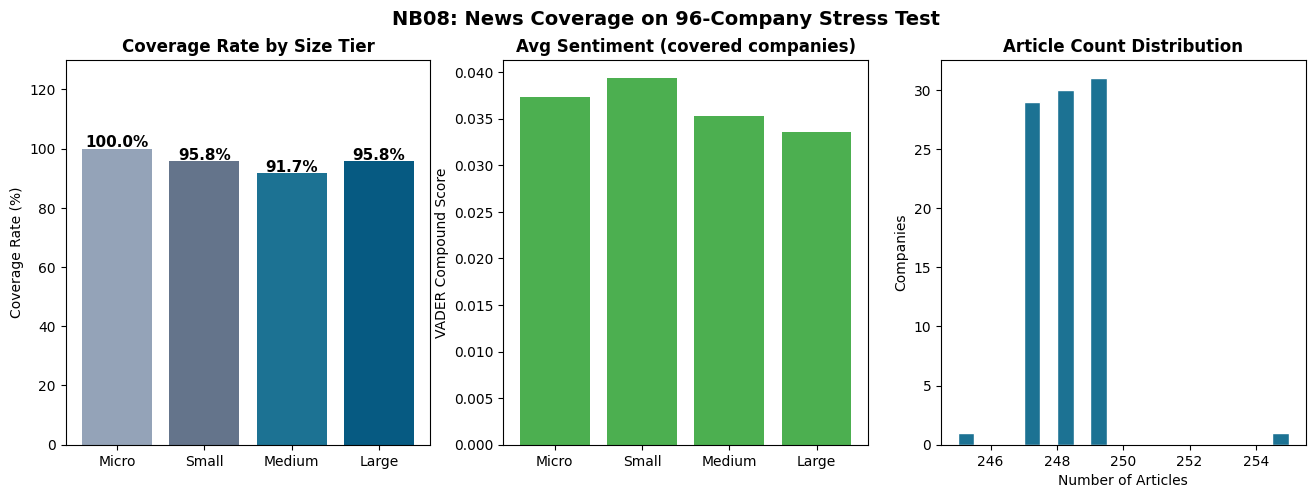

In [20]:
#Visualizations 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Coverage by tier
tier_order = ["Micro", "Small", "Medium", "Large"]
tier_data = signals_df.groupby("segment")["has_coverage"].mean().reindex(tier_order) * 100
bars = axes[0].bar(tier_order, tier_data.values, color=["#94A3B8", "#64748B", "#1C7293", "#065A82"])
axes[0].set_title("Coverage Rate by Size Tier", fontweight="bold")
axes[0].set_ylabel("Coverage Rate (%)")
axes[0].set_ylim(0, max(tier_data.values.max() * 1.3, 15))
for bar, val in zip(bars, tier_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

# 2. Avg sentiment by tier (for companies WITH coverage)
covered = signals_df[signals_df["has_coverage"]]
if len(covered) > 0:
    sent_by_tier = covered.groupby("segment")["avg_vader_compound"].mean().reindex(tier_order)
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in sent_by_tier.values]
    axes[1].bar(tier_order, sent_by_tier.values, color=colors)
    axes[1].set_title("Avg Sentiment (covered companies)", fontweight="bold")
    axes[1].set_ylabel("VADER Compound Score")
    axes[1].axhline(y=0, color="gray", linewidth=0.5)
else:
    axes[1].text(0.5, 0.5, "No companies\nwith coverage", ha="center", va="center", fontsize=14)
    axes[1].set_title("Avg Sentiment (covered companies)", fontweight="bold")

# 3. Article count distribution
if len(covered) > 0:
    axes[2].hist(covered["n_articles"], bins=20, color="#1C7293", edgecolor="white")
    axes[2].set_title("Article Count Distribution", fontweight="bold")
    axes[2].set_xlabel("Number of Articles")
    axes[2].set_ylabel("Companies")
else:
    axes[2].text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)

plt.suptitle("NB08: News Coverage on 96-Company Stress Test", fontsize=14, fontweight="bold")

plt.show()

## Spine Output
Export the final signals table so it can be joined onto Samuel's DuckDB spine via `CompanyNumber`.

In [26]:
# Build spine-ready output
spine_cols = ["CompanyNumber", "CompanyName", "segment", "sector",
    "n_articles", "has_coverage", "coverage_score",
    "guardian_articles", "gnews_articles",
    "avg_vader_compound", "avg_textblob_polarity", "sentiment_label",
    "news_signal"]


spine_signals = signals_df[spine_cols].copy()

output_path = SAMPLE_PATH.parent / "nb08_spine_news_signals.csv"
spine_signals.to_csv(output_path, index=False)
print(f"Saved {len(spine_signals)} rows to {output_path}")
print(f"\nPreview:")
print(spine_signals.head(10).to_string(index=False))

Saved 96 rows to C:\Users\visha\Lloyds_Github\data\processed\nb08_spine_news_signals.csv

Preview:
CompanyNumber                                         CompanyName segment                 sector  n_articles  has_coverage  coverage_score  guardian_articles  gnews_articles  avg_vader_compound  avg_textblob_polarity sentiment_label  news_signal
     09803195                                          WHALAR LTD   Large Fast growth & emerging         249          True             1.0                249               0               0.030                  0.061         neutral        0.854
     15336152                                             NCB RIP   Large Fast growth & emerging         249          True             1.0                249               0               0.030                  0.061         neutral        0.854
     12329778 EXODUSPOINT CAPITAL MANAGEMENT UK TECHNOLOGIES, LTD   Large Fast growth & emerging         249          True             1.0                249      